In [42]:
#Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import skew
%matplotlib inline

In [43]:
#Load the Data
#The adverstiting dataset captures sales revenue generated with respect to advertisement 
#spends across multiple channles like radio, tv and newspaper.
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams['figure.figsize'] = (12, 8)

In [44]:
df=pd.read_csv('Advertising.csv')

In [45]:
df.head(10)

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,10.6


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [68]:
df.describe()

,TV,radio,newspaper,sales,interaction
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500,3490.309900
std,85.854236,14.846809,21.778621,5.217457,3360.740127
min,0.700000,0.000000,0.300000,1.600000,0.000000
25%,74.375000,9.975000,12.750000,10.375000,773.445000
50%,149.750000,22.900000,25.750000,12.900000,2069.065000
75%,218.825000,36.525000,45.100000,17.400000,5516.197500
max,296.400000,49.600000,114.000000,27.000000,13540.410000


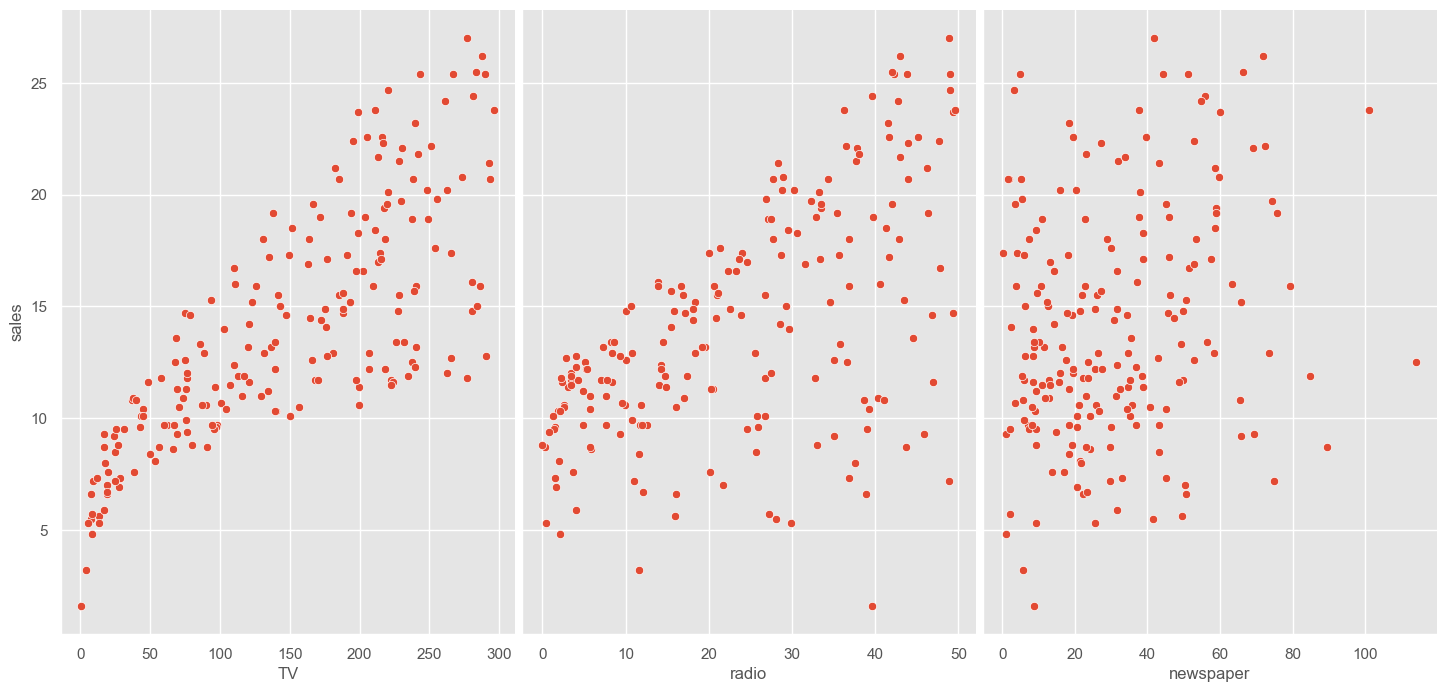

In [47]:
#Relationship between Features and Response
sns.pairplot(df,x_vars=['TV','radio','newspaper'],y_vars='sales',height=7,aspect=0.7)

In [48]:
#Multiple Linear Regression - Estimating Coefficients
from sklearn.linear_model import LinearRegression
x=df.drop('sales',axis=1)
y=df['sales']
lm1=LinearRegression()
lm1.fit(x,y)
print(lm1.intercept_)
print(lm1.coef_)

2.938889369459412
[ 0.04576465  0.18853002 -0.00103749]


In [49]:
list(zip(['TV','radio','newspaper'],lm1.coef_))

[('TV', 0.0457646454553976),
 ('radio', 0.18853001691820445),
 ('newspaper', -0.0010374930424763285)]

In [70]:
#The code sns.heatmap(df.corr(), annot=True) generates a correlation heatmap 
#df.corr():
#This part calculates the pairwise correlation between all numerical columns in your Pandas DataFrame df. 
#By default, it uses the Pearson correlation coefficient, which measures the linear relationship between
#two variables. The result is a correlation matrix where each cell represents the correlation coefficient 
#between two specific columns.
#It takes a 2D dataset (like the correlation matrix generated by df.corr()) 
#and visualizes it using a color-coded grid
#annot=True:
#This argument is crucial for displaying the actual correlation values within each cell of the heatmap. 
#If annot were set to False (the default), you would only see the color-coded representation 
#without the numerical values, making it harder to interpret the exact strength of the correlations.

<AxesSubplot:>

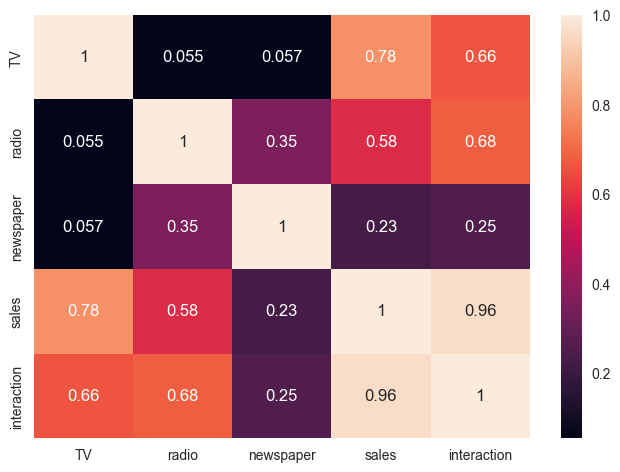

In [69]:
sns.heatmap(df.corr(),annot=True)

In [51]:
#Feature Selection
from sklearn.metrics import r2_score
lm2=LinearRegression()
lm2.fit(x[['TV','radio']],y)
lm2_pred=lm2.predict(x[['TV','radio']])
print(r2_score(y,lm2_pred))

0.8971942610828957


In [71]:
#Linear regression analysis is used to predict the value of a variable based on the value of another variable.
#The variable you want to predict is called the dependent variable.
lm3=LinearRegression()
lm3.fit(x[['TV','radio','newspaper']],y)
lm3_pred=lm3.predict(x[['TV','radio','newspaper']])
print(r2_score(y,lm3_pred))

0.8972106381789522


In [53]:
#train/test split with RMSE to see whether newspaper should be kept in the model:

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
X=df.drop('sales',axis=1)
y=df['sales']
x_train,x_test,y_train,y_test=train_test_split(X,y,random_state=1)
                                            
lm4=LinearRegression().fit(x_train,y_train)
lm4_pred=lm4.predict(x_test)
print("RMSE:",np.sqrt(mean_squared_error(y_test,lm4_pred)))
print("R*2:",r2_score(y_test,lm4_pred))

RMSE: 1.404651423032896
R*2: 0.9156213613792231


In [54]:
X=df.drop(['sales','newspaper'],axis=1)
y=df['sales']
x_train,x_test,y_train,y_test=train_test_split(X,y,random_state=1)
                                            
lm5=LinearRegression().fit(x_train,y_train)
lm5_pred=lm5.predict(x_test)
print("RMSE:",np.sqrt(mean_squared_error(y_test,lm5_pred)))
print("R*2:",r2_score(y_test,lm5_pred))

RMSE: 1.3879034699382888
R*2: 0.9176214942248907


In [55]:
df['interaction']=df['TV']*df['radio']
X=df[['TV','radio','interaction']]
y=df['sales']
x_train,x_test,y_train,y_test=train_test_split(X,y,random_state=1)
                                            
lm6=LinearRegression().fit(x_train,y_train)
lm6_pred=lm6.predict(x_test)
print("RMSE:",np.sqrt(mean_squared_error(y_test,lm6_pred)))
print("R*2:",r2_score(y_test,lm6_pred))

RMSE: 0.7011871137164328
R*2: 0.978973681468126


In [60]:
from sklearn.datasets import make_classification

In [61]:
from sklearn.model_selection import train_test_split

In [64]:
from yellowbrick.classifier import ClassPredictionError

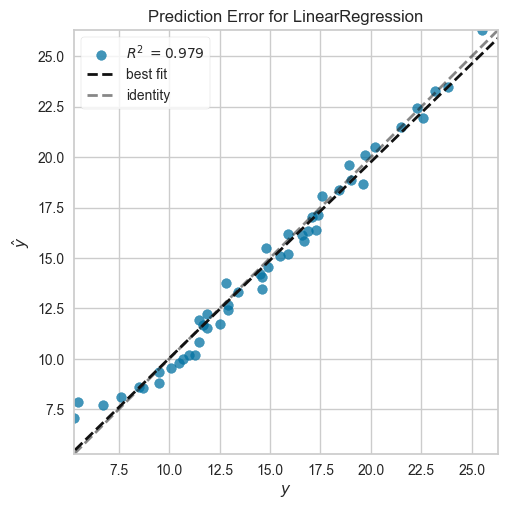

In [65]:
from yellowbrick.regressor import PredictionError,ResidualsPlot
v=PredictionError(lm5).fit(x_train,y_train)
v.score(x_test,y_test)
v.poof()

In [66]:
df['interaction']=df['TV']*df['radio']
X=df[['TV','radio','interaction']]
y=df['sales']
x_train,x_test,y_train,y_test=train_test_split(X,y,random_state=1)
                                            
lm6=LinearRegression().fit(x_train,y_train)
lm6_pred=lm6.predict(x_test)
print("RMSE:",np.sqrt(mean_squared_error(y_test,lm6_pred)))
print("R*2:",r2_score(y_test,lm6_pred))

RMSE: 0.7011871137164328
R*2: 0.978973681468126


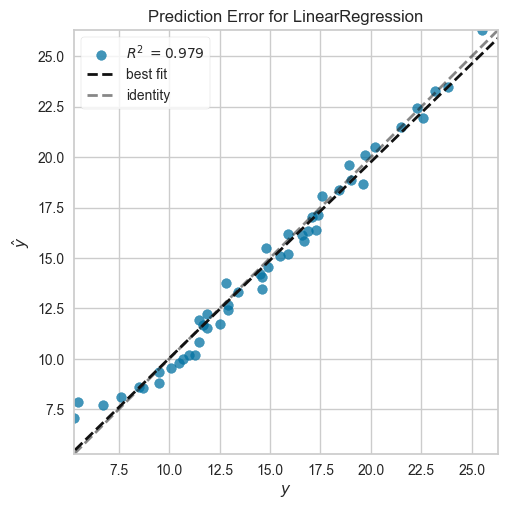

In [67]:
v=PredictionError(lm6).fit(x_train,y_train)
v.score(x_test,y_test)
v.poof()